# Self-Organizing Map with Genetic Algorithm

Import the libraries

In [1]:
import numpy as np
import pandas as pd
import pygad
import matplotlib.pyplot as plt 
from minisom import MiniSom
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer 

Import the dataset

In [2]:
dataset = pd.read_csv('Churn_Modelling.csv')
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

Data preprocessing

Label encoding for "Gender" column

In [3]:
label_encoder = LabelEncoder()
X[:, 2] = label_encoder.fit_transform(X[:, 2])

One Hot encoding for "Country" column

In [4]:
column_transformer = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(column_transformer.fit_transform(X))

Feature Scaling

In [5]:
sc = MinMaxScaler(feature_range=(0, 1))
X = sc.fit_transform(X)

Create the SOM

In [6]:
som = MiniSom(x=10, y=10, input_len=12, sigma=1.0, learning_rate=0.5)
som.random_weights_init(X)

Create the fitness function

In [7]:
def fitness_function(instance, solution, solution_idx):
    # Reshape the solution array into the shape of the SOM weights
    weights = solution.reshape((10, 10, 12))

    # Initialize the SOM with the weights
    som = MiniSom(x=10, y=10, input_len=12, sigma=1.0, learning_rate=0.5)

    # Set the weights of the SOM
    som.__setattr__('weights', weights)

    num_classes = len(np.unique(y))
    y_counts = np.zeros((num_classes, len(X)))
    
    for i, x in enumerate(X):
        w = som.winner(x)
        predicted_class = np.argmax(y.reshape(-1, num_classes)[w[0]*10+w[1], :])
        y_counts[predicted_class, i] += 1
    
    y_pred = np.argmax(y_counts, axis=0)
    fitness = (y_pred == y).mean()


    return fitness

Create the PyGAD optimizer

In [8]:
ga_instance = pygad.GA(num_generations=100,
              num_parents_mating=5,
              sol_per_pop=10,
              num_genes=1200,
              fitness_func=fitness_function)

Run the optimizer

In [9]:
ga_instance.run()

In [10]:
best_solution = ga_instance.best_solution()

In [11]:
best_solution_array = np.array(best_solution, dtype=object)
best_weights = best_solution_array[0].reshape(10, 10, 12)

Create a new SOM object with the best weights

In [12]:
best_som = MiniSom(x=10, y=10, input_len=12, sigma=1.0, learning_rate=0.5)
best_som.weights = best_weights

In [13]:
best_som.train_random(X, 1000)

Use the SOM to predict the labels

In [14]:
y_pred = np.zeros(len(X))
for i, x in enumerate(X):
    w = best_som.winner(x)
    predicted_class = y[w[0]*10+w[1]]
    y_pred[i] = predicted_class

In [15]:
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y.reshape(len(y), 1)), 1))

[[0 1]
 [0 0]
 [0 1]
 ...
 [0 1]
 [0 1]
 [1 0]]


Print the classification report and confusion matrix

In [16]:
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84      7963
           1       0.23      0.14      0.18      2037

    accuracy                           0.73     10000
   macro avg       0.52      0.51      0.51     10000
weighted avg       0.69      0.73      0.70     10000

[[7028  935]
 [1751  286]]


In [17]:
accuracy = accuracy_score(y, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.7314


In [18]:
cm = confusion_matrix(y, y_pred)
print(cm)

[[7028  935]
 [1751  286]]


Plot the SOM and the predicted classes

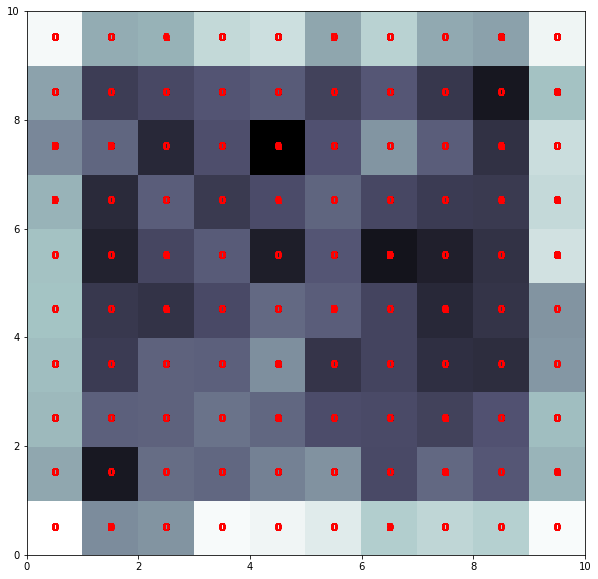

In [19]:
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='bone_r')
for i, x in enumerate(X):
    w = som.winner(x)
    plt.text(w[0]+0.5, w[1]+0.5, str(int(y_pred[i])), color='red', ha='center', va='center', fontweight='bold')
plt.xlim((0, som.get_weights().shape[0]))
plt.ylim((0, som.get_weights().shape[1]))
plt.show()

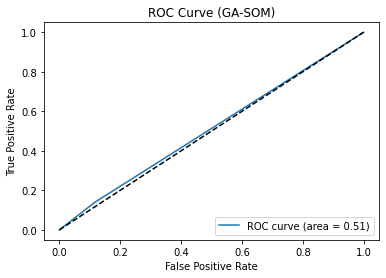

In [23]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate the ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y, y_pred)
auc_score = roc_auc_score(y, y_pred)

# Create ROC curve plot
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (GA-SOM)')
plt.legend(loc='lower right')
plt.show()

In [21]:
som_tp=7028
som_tn=286
som_fp=935
som_fn=1751
sensitivity = som_tp/(som_tp+som_fn)
precision = som_tp/(som_tp+som_fp)
recall=som_tp/(som_tp + som_tn)
f1_score = 2*(precision * recall)/(precision+recall)
print("Sensitivity:", sensitivity)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Sensitivity: 0.8005467593119945
Precision: 0.882581941479342
Recall: 0.9608969100355482
F1 Score: 0.9200759311383124


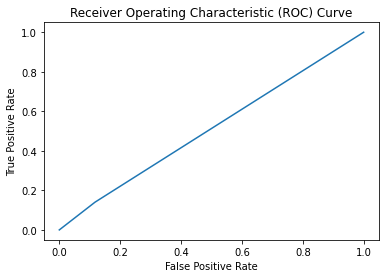

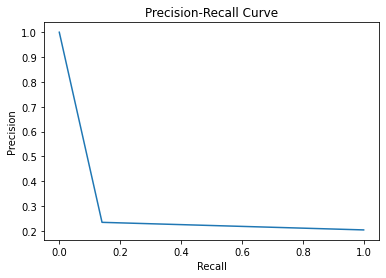

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have the true labels (y_true) and predicted probabilities (y_pred)
# for the positive class from your model

# Compute ROC curve
fpr, tpr, thresholds_roc = roc_curve(y, y_pred)

# Compute precision-recall curve
precision, recall, thresholds_pr = precision_recall_curve(y, y_pred)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

# Plot PR curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()